# Análise e Limpeza de Dados de Vítimas de Acidentes de Trânsito

Este notebook apresenta o processo de análise, limpeza e preparação dos dados de vítimas de acidentes de trânsito do município de São Paulo, utilizando a base RENAEST. O objetivo é preparar os dados para análises estatísticas e geração de insights relevantes para a segurança viária.

## Instalação e Importação de Bibliotecas
Certifique-se de que o pandas está instalado. Em seguida, importe as bibliotecas necessárias.

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os

## Carregamento dos Dados
Carregue o arquivo CSV com os dados de vítimas. O caminho deve ser ajustado conforme a estrutura de pastas do projeto.

In [3]:
csv_path = 'dataset/renaest_dabertos_20250412/Vitimas_DadosAbertos_20250412.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path, sep=';', encoding='utf-8', low_memory=False)
    print('Arquivo carregado com sucesso!')
else:
    print(f"Arquivo não encontrado: {csv_path}")

Arquivo carregado com sucesso!


## Inspeção Inicial dos Dados
Visualize as primeiras linhas, informações gerais e estatísticas descritivas do dataset.

In [4]:
display(df.head())
df.info()
df.describe()

,num_acidente,chv_localidade,data_acidente,uf_acidente,ano_acidente,mes_acidente,mes_ano_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
0,6371628,AC1200401201801,2018-01-11,AC,2018,1,12018,ENTRE 35 E 39 ANOS,MASCULINO,MOTORISTA,LEVE,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
1,6465295,AC1200401201801,2018-01-28,AC,2018,1,12018,ENTRE 50 E 54 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
2,6243850,AC1200401201801,2018-01-21,AC,2018,1,12018,ENTRE 35 E 39 ANOS,MASCULINO,MOTORISTA,LEVE,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
3,4148327,AC1200401201801,2018-01-20,AC,2018,1,12018,ENTRE 35 E 39 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
4,610193,AC1200401201801,2018-01-29,AC,2018,1,12018,ENTRE 55 E 59 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10612770 entries, 0 to 10612769
Data columns (total 17 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   num_acidente        int64 
 1   chv_localidade      object
 2   data_acidente       object
 3   uf_acidente         object
 4   ano_acidente        int64 
 5   mes_acidente        int64 
 6   mes_ano_acidente    int64 
 7   faixa_idade         object
 8   genero              object
 9   tp_envolvido        object
 10  gravidade_lesao     object
 11  equip_seguranca     object
 12  ind_motorista       object
 13  susp_alcool         object
 14  qtde_envolvidos     int64 
 15  qtde_feridosilesos  int64 
 16  qtde_obitos         int64 
dtypes: int64(7), object(10)
memory usage: 1.3+ GB


,num_acidente,ano_acidente,mes_acidente,mes_ano_acidente,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
count,1.061277e+07,1.061277e+07,1.061277e+07,1.061277e+07,1.061277e+07,1.061277e+07,1.061277e+07
mean,3.519618e+06,2.021163e+03,6.646982e+00,6.849098e+04,9.628243e-01,9.483557e-01,1.446861e-02
std,2.032336e+06,1.928103e+00,3.442085e+00,3.442082e+04,3.782431e-01,3.937681e-01,1.224925e-01
min,1.000000e+00,2.018000e+03,1.000000e+00,1.201800e+04,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.759203e+06,2.019000e+03,4.000000e+00,4.201900e+04,1.000000e+00,1.000000e+00,0.000000e+00
50%,3.519888e+06,2.021000e+03,7.000000e+00,7.201900e+04,1.000000e+00,1.000000e+00,0.000000e+00
75%,5.278790e+06,2.023000e+03,1.000000e+01,1.020190e+05,1.000000e+00,1.000000e+00,0.000000e+00
max,7.039437e+06,2.024000e+03,1.200000e+01,1.220240e+05,7.500000e+01,7.500000e+01,1.200000e+01


## Limpeza Inicial dos Dados
Remova colunas totalmente vazias e linhas duplicadas.

In [5]:
df_limpo = df.dropna(axis=1, how='all')
df_limpo = df_limpo.drop_duplicates()
display(df_limpo.head())
df_limpo.info()

,num_acidente,chv_localidade,data_acidente,uf_acidente,ano_acidente,mes_acidente,mes_ano_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
0,6371628,AC1200401201801,2018-01-11,AC,2018,1,12018,ENTRE 35 E 39 ANOS,MASCULINO,MOTORISTA,LEVE,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
1,6465295,AC1200401201801,2018-01-28,AC,2018,1,12018,ENTRE 50 E 54 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
2,6243850,AC1200401201801,2018-01-21,AC,2018,1,12018,ENTRE 35 E 39 ANOS,MASCULINO,MOTORISTA,LEVE,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
3,4148327,AC1200401201801,2018-01-20,AC,2018,1,12018,ENTRE 35 E 39 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
4,610193,AC1200401201801,2018-01-29,AC,2018,1,12018,ENTRE 55 E 59 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10612770 entries, 0 to 10612769
Data columns (total 17 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   num_acidente        int64 
 1   chv_localidade      object
 2   data_acidente       object
 3   uf_acidente         object
 4   ano_acidente        int64 
 5   mes_acidente        int64 
 6   mes_ano_acidente    int64 
 7   faixa_idade         object
 8   genero              object
 9   tp_envolvido        object
 10  gravidade_lesao     object
 11  equip_seguranca     object
 12  ind_motorista       object
 13  susp_alcool         object
 14  qtde_envolvidos     int64 
 15  qtde_feridosilesos  int64 
 16  qtde_obitos         int64 
dtypes: int64(7), object(10)
memory usage: 1.3+ GB


## Filtragem dos Dados para São Paulo a partir de 2020
Selecione apenas as vítimas de acidentes ocorridos a partir de 2020, no município de São Paulo.

In [8]:
df_sp = df_limpo[(df_limpo['ano_acidente'] >= 2020) & (df_limpo['uf_acidente'] == 'SP') &  (df_limpo['chv_localidade'].str.startswith('SP3550308'))]
display(df_sp.head())

,num_acidente,chv_localidade,data_acidente,uf_acidente,ano_acidente,mes_acidente,mes_ano_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
9321337,3682956,SP3550308202001,2020-01-12,SP,2020,1,12020,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO,NAO INFORMADO,0,0,0
9321338,406687,SP3550308202001,2020-01-07,SP,2020,1,12020,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321339,878731,SP3550308202001,2020-01-13,SP,2020,1,12020,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321340,797005,SP3550308202001,2020-01-16,SP,2020,1,12020,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321341,2367520,SP3550308202001,2020-01-30,SP,2020,1,12020,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


### Contar valores únicos em todas as colunas
Esta função retorna a quantidade de valores únicos e os próprios valores únicos para cada coluna do DataFrame.

In [9]:
def contar_valores_unicos_todas_colunas(df):
    resultado = {}
    for col in df.columns:
        n_unicos = df[col].nunique()
        valores_unicos = df[col].unique()
        resultado[col] = {'quantidade': n_unicos, 'valores': valores_unicos}
    return resultado

# Exemplo de uso:
contagem_unicos = contar_valores_unicos_todas_colunas(df_sp)
for coluna, info in contagem_unicos.items():
    print(f'{coluna}: {info["quantidade"]} valores únicos')

num_acidente: 219124 valores únicos
chv_localidade: 60 valores únicos
data_acidente: 1827 valores únicos
uf_acidente: 1 valores únicos
ano_acidente: 5 valores únicos
mes_acidente: 12 valores únicos
mes_ano_acidente: 60 valores únicos
faixa_idade: 15 valores únicos
genero: 4 valores únicos
tp_envolvido: 5 valores únicos
gravidade_lesao: 6 valores únicos
equip_seguranca: 1 valores únicos
ind_motorista: 2 valores únicos
susp_alcool: 1 valores únicos
qtde_envolvidos: 8 valores únicos
qtde_feridosilesos: 8 valores únicos
qtde_obitos: 5 valores únicos


### Função para contar valores 'DESCONHECIDO' ou 'NAO INFORMADO' em todas as colunas
Esta função percorre todas as colunas do DataFrame e retorna a contagem desses valores para cada coluna.

In [10]:
def contar_desconhecido_ou_nao_informado(df):
    resultado = {}
    for col in df.columns:
        count = df[col].isin(['DESCONHECIDO', 'NAO INFORMADO']).sum()
        if count > 0:
            resultado[col] = count
    return resultado

# Exemplo de uso:
contagem = contar_desconhecido_ou_nao_informado(df_sp)
print('Contagem de "DESCONHECIDO" ou "NAO INFORMADO" por coluna:')
for coluna, qtd in contagem.items():
    print(f'{coluna}: {qtd}')

Contagem de "DESCONHECIDO" ou "NAO INFORMADO" por coluna:
faixa_idade: 166195
genero: 148746
tp_envolvido: 186165
gravidade_lesao: 165569
equip_seguranca: 285262
susp_alcool: 285262


## Remoção de Colunas Irrelevantes
Removeremos do dataset as colunas que não são necessárias para a análise ou que possuem apenas valores ausentes ou redundantes. Ajuste a lista conforme a análise anterior.

In [14]:
colunas_remover = [
    'chv_localidade', 'latitude_acidente', 'longitude_acidente', 
    'uf_acidente', 'ano_acidente', 'mes_acidente', 'mes_ano_acidente',
    'bairro_acidente', 'cep_acidente'
]
df_sp_limpo = df_sp.drop(columns=[col for col in colunas_remover if col in df_sp.columns])
display(df_sp_limpo.head())

,num_acidente,data_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
9321337,3682956,2020-01-12,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO,NAO INFORMADO,0,0,0
9321338,406687,2020-01-07,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321339,878731,2020-01-13,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321340,797005,2020-01-16,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321341,2367520,2020-01-30,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


## Salvar Dataset Limpo
Salve o DataFrame limpo em um novo arquivo CSV para uso posterior.

In [ ]:
output_path = 'dataset/renaest_dabertos_20250412/Vitimas_DadosAbertos_20250412_limpo.csv'
df_sp_limpo.to_csv(output_path, sep=';', index=False, encoding='utf-8')
print(f"Dataset limpo salvo em: {output_path}")

## Considerações Finais
O dataset foi limpo, filtrado e salvo, estando pronto para análises estatísticas, geração de gráficos e elaboração de relatórios acadêmicos.

## Sugestões de Análises Estatísticas das Vítimas

- Distribuição das vítimas por tipo (condutor, passageiro, pedestre)
- Vítimas por faixa etária
- Vítimas por sexo
- Vítimas por gravidade (ileso, ferido, óbito)
- Vítimas por tipo de acidente
- Vítimas por horário e dia da semana

Adapte e expanda conforme o foco do seu trabalho acadêmico.

In [21]:
import matplotlib.pyplot as plt

In [24]:
#Exibir 50 primeiras linhas
display(df_sp_limpo.head(50))

#Exibir valores distintos da coluna gravidade_lesao
display(df_sp_limpo['gravidade_lesao'].unique())
# Considera apenas vítimas fatais
vitimas_fatais = df_sp_limpo[df_sp_limpo['gravidade_lesao'] == 'OBITO']

# Conta óbitos por sexo
obitos_por_sexo = vitimas_fatais['genero'].value_counts()
total_obitos = obitos_por_sexo.sum()
percentuais = (obitos_por_sexo / total_obitos * 100).round(1)

# Garante que ambos os sexos estejam presentes para evitar KeyError
masc = percentuais.get('MASCULINO', 0)
fem = percentuais.get('FEMININO', 0)

print(
    f"A análise demográfica das vítimas fatais indicou um perfil predominante. "
    f"Do total de óbitos ({total_obitos}), {masc}% eram do sexo masculino e {fem}% do sexo feminino."
)

,num_acidente,data_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
9321337,3682956,2020-01-12,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO,NAO INFORMADO,0,0,0
9321338,406687,2020-01-07,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321339,878731,2020-01-13,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321340,797005,2020-01-16,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321341,2367520,2020-01-30,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,SEM FERIMENTO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
9321346,5818020,2020-01-03,ENTRE 30 E 34 ANOS,FEMININO,PASSAGEIROS,LEVE,NAO INFORMADO,NAO,NAO INFORMADO,1,1,0
9321350,3552919,2020-01-14,ENTRE 30 E 34 ANOS,MASCULINO,PASSAGEIROS,LEVE,NAO INFORMADO,NAO,NAO INFORMADO,1,1,0
9321354,3101961,2020-01-21,ENTRE 35 E 39 ANOS,MASCULINO,DESCONHECIDO,LEVE,NAO INFORMADO,NAO,NAO INFORMADO,1,1,0
9321355,3802693,2020-01-22,ENTRE 35 E 39 ANOS,MASCULINO,DESCONHECIDO,LEVE,NAO INFORMADO,NAO,NAO INFORMADO,1,1,0
9321360,4865322,2020-01-17,ENTRE 35 E 39 ANOS,FEMININO,MOTORISTA,LEVE,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


array(['NAO INFORMADO', 'SEM FERIMENTO', 'LEVE', 'OBITO', 'DESCONHECIDO',
       'GRAVE'], dtype=object)

A análise demográfica das vítimas fatais indicou um perfil predominante. Do total de óbitos (4201), 83.8% eram do sexo masculino e 15.8% do sexo feminino.


A faixa etária mais atingida foi a de ENTRE 18 E 24 ANOS, concentrando 17.5% das fatalidades (Figura C - Gráfico de barras/pizza por faixa etária e gênero).


<Figure size 1000x500 with 0 Axes>

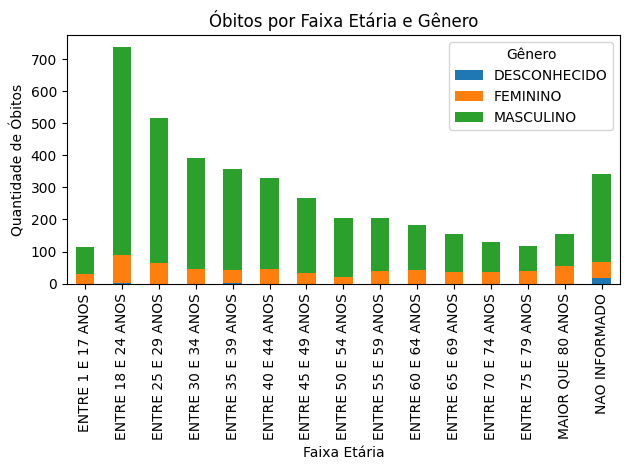

In [34]:

# Conta óbitos por faixa etária
obitos_por_faixa = vitimas_fatais['faixa_idade'].value_counts().sort_values(ascending=False)
total_obitos = obitos_por_faixa.sum()
percentuais_faixa = (obitos_por_faixa / total_obitos * 100).round(1)


# Pega a faixa etária mais atingida
faixa_mais_atingida = percentuais_faixa.index[0]
percentual_mais_atingida = percentuais_faixa.iloc[0]

print(
    f"A faixa etária mais atingida foi a de {faixa_mais_atingida}, concentrando {percentual_mais_atingida}% das fatalidades (Figura C - Gráfico de barras/pizza por faixa etária e gênero)."


)

# Gráfico de barras por faixa etária e gênero

plt.figure(figsize=(10,5))
vitimas_fatais.groupby(['faixa_idade', 'genero']).size().unstack().plot(kind='bar', stacked=True)
plt.title('Óbitos por Faixa Etária e Gênero')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Óbitos')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

C:\Users\freda\AppData\Local\Temp\ipykernel_28428\3016354657.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vitimas_fatais['ano'] = pd.to_datetime(vitimas_fatais['data_acidente']).dt.year


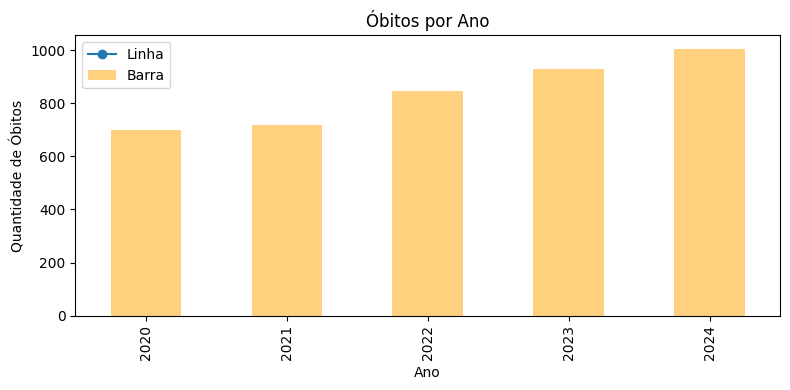

Observou-se uma leve aumento no número absoluto de mortes ao longo dos anos analisados (Figura X - Gráfico de linha/barra por ano).


In [33]:
# Análise da tendência anual de mortes
# Considera apenas vítimas fatais
vitimas_fatais = df_sp_limpo[df_sp_limpo['gravidade_lesao'] == 'OBITO']

# Extrai o ano do acidente
vitimas_fatais['ano'] = pd.to_datetime(vitimas_fatais['data_acidente']).dt.year

# Conta óbitos por ano
obitos_por_ano = vitimas_fatais['ano'].value_counts().sort_index()

# Exibe gráfico de linha e barra
plt.figure(figsize=(8,4))
obitos_por_ano.plot(marker='o', linestyle='-', label='Linha')
obitos_por_ano.plot(kind='bar', alpha=0.5, color='orange', label='Barra')
plt.title('Óbitos por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Óbitos')
plt.legend(['Linha', 'Barra'])
plt.tight_layout()
plt.show()

# Descreve a tendência geral
if obitos_por_ano.is_monotonic_increasing:
    tendencia = 'leve aumento'
elif obitos_por_ano.is_monotonic_decreasing:
    tendencia = 'queda'
else:
    tendencia = 'estabilidade'

print(f"Observou-se uma {tendencia} no número absoluto de mortes ao longo dos anos analisados (Figura X - Gráfico de linha/barra por ano).")

In [35]:
#Quantidade de dias entre o dia 01/01/2020 e 31/12/2024
dias = (pd.to_datetime('2024-12-31') - pd.to_datetime('2020-01-01')).days + 1

#Quantidade média de mortes por dia
media_diaria = total_obitos / dias
print(
    f"Entre 2020 e 2024, ocorreram {total_obitos} óbitos, resultando em uma média de {media_diaria:.2f} mortes por dia."
    
)

#Mortes por 100.000 habitantes
populacao_2024 = 11451999  # População estimada de São Paulo em 2024
#fonte IBGE, Diretoria de Pesquisas, Coordenação de População e Indicadores Sociais, Estimativas da população residente com data de referência 1o de julho de 2024


total_obitos_2024 = vitimas_fatais[vitimas_fatais['data_acidente'].str.startswith('2024')].shape[0]
#Mortes por 100k em 2024
mortes_por_100k_2024 = (total_obitos_2024 / populacao_2024) * 100000

print(
    f"Isso representa {mortes_por_100k_2024:.2f} mortes por 100.000 habitantes."
)


Entre 2020 e 2024, ocorreram 4201 óbitos, resultando em uma média de 2.30 mortes por dia.
Isso representa 36.68 mortes por 100.000 habitantes.
Isso representa 8.78 mortes por 100.000 habitantes.


## Distribuição Mensal dos Óbitos

Verificou-se uma maior concentração de óbitos durante os meses do ano (Figura Y - Gráfico de barras por mês), permitindo identificar possíveis sazonalidades ou períodos críticos para a ocorrência de fatalidades no trânsito.

C:\Users\freda\AppData\Local\Temp\ipykernel_28428\4180719257.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vitimas_fatais['mes'] = pd.to_datetime(vitimas_fatais['data_acidente']).dt.month


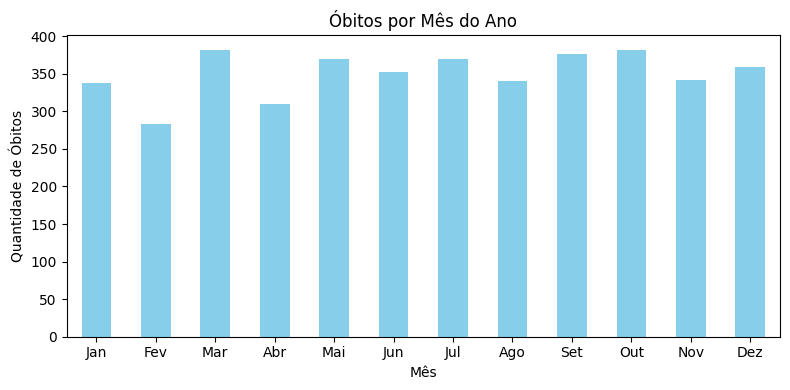

Verificou-se uma maior concentração de óbitos durante o(s) mês(es): Outubro.


In [36]:
# Distribuição mensal dos óbitos
# Considera apenas vítimas fatais
vitimas_fatais = df_sp_limpo[df_sp_limpo['gravidade_lesao'] == 'OBITO']

# Extrai o mês do acidente
vitimas_fatais['mes'] = pd.to_datetime(vitimas_fatais['data_acidente']).dt.month

# Conta óbitos por mês
obitos_por_mes = vitimas_fatais['mes'].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(8,4))
obitos_por_mes.plot(kind='bar', color='skyblue')
plt.title('Óbitos por Mês do Ano')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Óbitos')
plt.xticks(ticks=range(0,12), labels=['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'], rotation=0)
plt.tight_layout()
plt.show()

# Identifica o(s) mês(es) com maior concentração de óbitos
max_obitos = obitos_por_mes.max()
meses_mais_obitos = [i for i, v in obitos_por_mes.items() if v == max_obitos]
nomes_meses = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho','Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']
meses_nome = ', '.join([nomes_meses[m-1] for m in meses_mais_obitos])

print(f"Verificou-se uma maior concentração de óbitos durante o(s) mês(es): {meses_nome}.")